In [4]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/meat-freshness-image-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'meat-freshness-image-dataset' dataset.
Path to dataset files: /kaggle/input/meat-freshness-image-dataset
Contents of base_path (/kaggle/input):
['meat-freshness-image-dataset']
Contents of path (/kaggle/input/meat-freshness-image-dataset):
['Meat Freshness.v1-new-dataset.multiclass']


In [5]:
import os

# Update path based on cell 1 results
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')

# List class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Data classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Data classes found: ['valid', 'train']



--- Displaying sample images from dataset (/kaggle/input/meat-freshness-image-dataset/Meat Freshness.v1-new-dataset.multiclass) ---
Found 2266 images. Displaying 6 sample images:


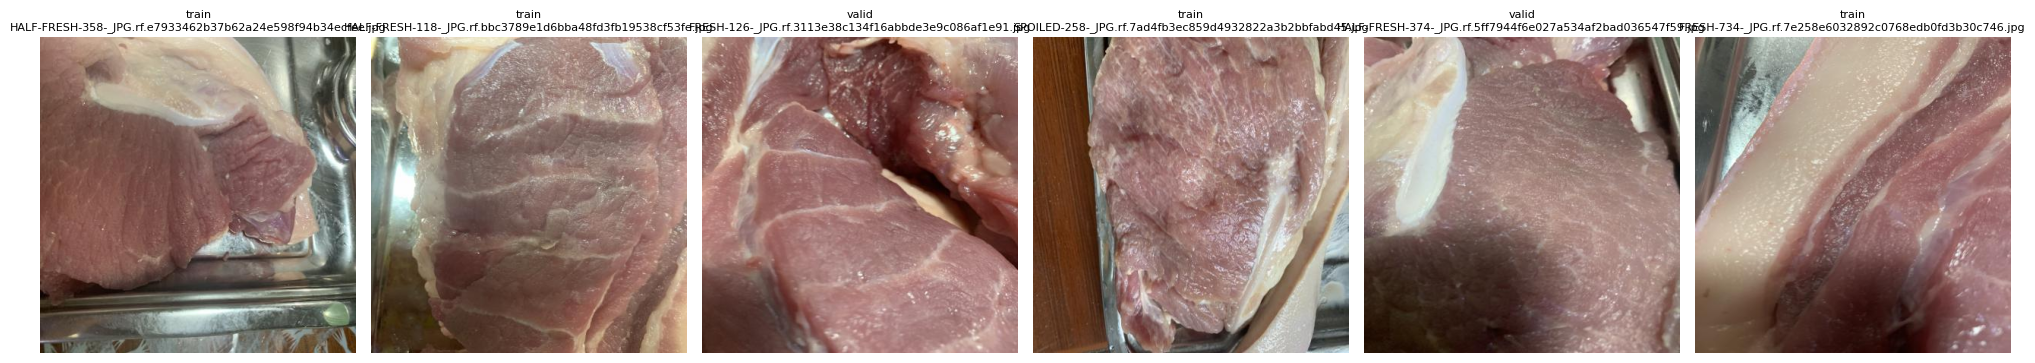

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use updated path
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')
print(f"\n--- Displaying sample images from dataset ({data_path}) ---")
display_sample_images(data_path)

In [7]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [10]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os

class MeatDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.classes = sorted(list(set([f.split('-')[0] for f in self.image_files])))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label_name = img_name.split('-')[0]
        label = self.class_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

# Transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Initialize custom datasets
image_datasets = {x: MeatDataset(os.path.join(data_path, x), data_transforms[x]) for x in ['train', 'valid']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True) for x in ['train', 'valid']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes

# Build VGG16
model = models.vgg16(weights='IMAGENET1K_V1')
for param in model.features.parameters():
    param.requires_grad = False

num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
print(f"Detected classes: {class_names}")
print("Model ready for training on GPU.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 93.2MB/s]


Detected classes: ['FRESH', 'HALF', 'SPOILED']
Model ready for training on GPU.


In [13]:
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=5):
    # Fixed: keys initialized to match the 'phase' values ('train' and 'valid')
    history = {'train_loss': [], 'train_acc': [], 'valid_loss': [], 'valid_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

model, history = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 1/10
train Loss: 0.4391 Acc: 0.9300
valid Loss: 0.1644 Acc: 0.9734
Epoch 2/10
train Loss: 0.3324 Acc: 0.9421
valid Loss: 0.1954 Acc: 0.9446
Epoch 3/10
train Loss: 0.3863 Acc: 0.9636
valid Loss: 0.5326 Acc: 0.9534
Epoch 4/10
train Loss: 0.3871 Acc: 0.9653
valid Loss: 1.1422 Acc: 0.9290
Epoch 5/10
train Loss: 0.6917 Acc: 0.9559
valid Loss: 1.5986 Acc: 0.9157
Epoch 6/10
train Loss: 0.8351 Acc: 0.9548
valid Loss: 0.2907 Acc: 0.9800
Epoch 7/10
train Loss: 0.7168 Acc: 0.9631
valid Loss: 0.2866 Acc: 0.9823
Epoch 8/10
train Loss: 0.9042 Acc: 0.9669
valid Loss: 0.6035 Acc: 0.9867
Epoch 9/10
train Loss: 0.6026 Acc: 0.9791
valid Loss: 0.5931 Acc: 0.9734
Epoch 10/10
train Loss: 0.3919 Acc: 0.9835
valid Loss: 0.4387 Acc: 0.9778


In [15]:
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['valid_acc'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history['valid_acc']):.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9835
Final Validation Accuracy: 0.9778
Best Validation Accuracy: 0.9867


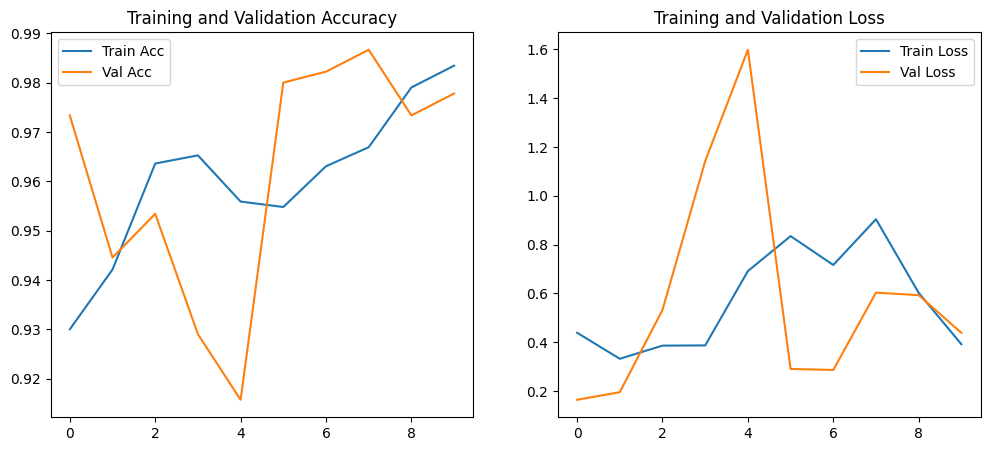

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['valid_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['valid_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()